# Import the Required Libraries #

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

## Import the CSV file Data as Pandas Data Frame #

In [3]:
df=pd.read_csv('/Volumes/E Drive/Learning Curve/Data Science Projects/ML Project/First ML Project/notebook/data/Studper.csv')
print(df.head())
df.shape

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


(1000, 8)

### 2.2 Dataset Information ###
##### 1. Gender: Sex of students --> (Male / Female)
##### 2. Race / Ethnicity: Ethnixity of Students:--> (Group A,B,C,D,E)
##### 3. Parental Level of Education: Bachelor Degree,College Student, Master Degree,Associate's degree 
##### 4. Lunch: Having lunch before test(Standard or Free / Reduced)
##### 5. Test Prep Course: Complete / Not complete befre test 
##### 6. Math Score
##### 7. Reading Score
##### 8. Writing Score


### 3. Data Checks to Perform and Analysis

#### Check Missing values
#### Checks Duplicates
#### Check data type
#### Check the number of unique values of each column
#### Check statistics of data set 
#### Check various categories present in the differnt categorical column 


In [4]:
# 3.1 Check the Missing values 
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
# Check the Duplicate values and test the number of duplicate values in the dataset
df.duplicated().sum()

np.int64(0)

In [6]:
# Check Null & Data Type Value
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Insights #

#### From above description of Numerical Data , all means are very close to each other between 66 and 68.05

#### All standard deviations are also close between14.6 and 15.19 
#### While there is minimum score 0 for math, for writing minimum is much higher = 10 and for reading mgiht higher=17

# Exploring Data

In [8]:
print("categories in 'gender' variable: ",end=" ")
print(df['gender'].unique())
print("categories in 'race/ethnicity' variable: ",end=" ")
print(df['race/ethnicity'].unique())
print("categories in 'parental level of education' variable: ",end=" ")
print(df['parental level of education'].unique())
print("categories in 'lunch' variable: ",end=" ")
print(df['lunch'].unique())
print("categories in 'test preparation course' variable: ",end=" ")
print(df['test preparation course'].unique())

categories in 'gender' variable:  <StringArray>
['female', 'male']
Length: 2, dtype: str
categories in 'race/ethnicity' variable:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
categories in 'parental level of education' variable:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
categories in 'lunch' variable:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
categories in 'test preparation course' variable:  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [9]:
# Define the categorical and numerical columns
numerical_features=[feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features=[feature for feature in df.columns if df[feature].dtype == 'O']
print('We have {} Numerical features: {}' .format(len(numerical_features),numerical_features)) 
print('We have {} Categorical features: {}' .format(len(categorical_features),categorical_features)) 

We have 8 Numerical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']
We have 0 Categorical features: []


## Adding Columns for "Total Score" and "Average"

In [10]:
df['Total Score']=df['math score']+df['reading score']+df['writing score']
df['Average Score']=df['Total Score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [11]:
reading_full= df[df['reading score']==100]['Average Score'].count()
writing_full= df[df['writing score']==100]['Average Score'].count()
math_full= df[df['math score']==100]['Average Score'].count()
print('Number of students who scored 100 in Reading: ',reading_full)
print('Number of students who scored 100 in Writing: ',writing_full)
print('Number of students who scored 100 in Math: ',math_full)

Number of students who scored 100 in Reading:  17
Number of students who scored 100 in Writing:  14
Number of students who scored 100 in Math:  7


In [12]:
reading_less_20=df[df['reading score']<20]['Average Score'].count()
writing_less_20=df[df['writing score']<20]['Average Score'].count()
math_less_20=df[df['math score']<20]['Average Score'].count()
print('Number of students who scored less than 20 in Reading: ',reading_less_20)
print('Number of students who scored less than 20 in Writing: ',writing_less_20)
print('Number of students who scored less than 20 in Math: ',math_less_20)

Number of students who scored less than 20 in Reading:  1
Number of students who scored less than 20 in Writing:  3
Number of students who scored less than 20 in Math:  4


#### 4.1 Histogram & KDE

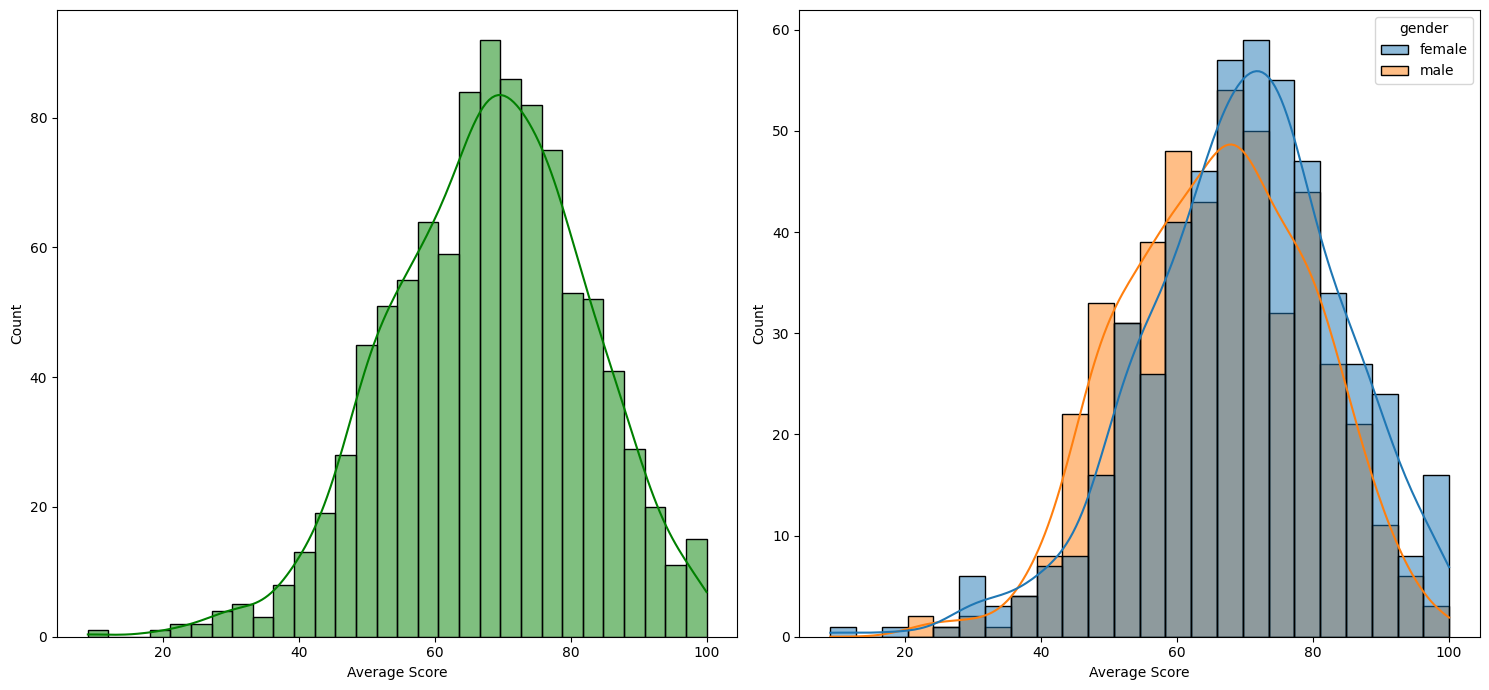

In [13]:
fig, axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Average Score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Average Score',kde=True,hue='gender')
plt.tight_layout()
plt.show()

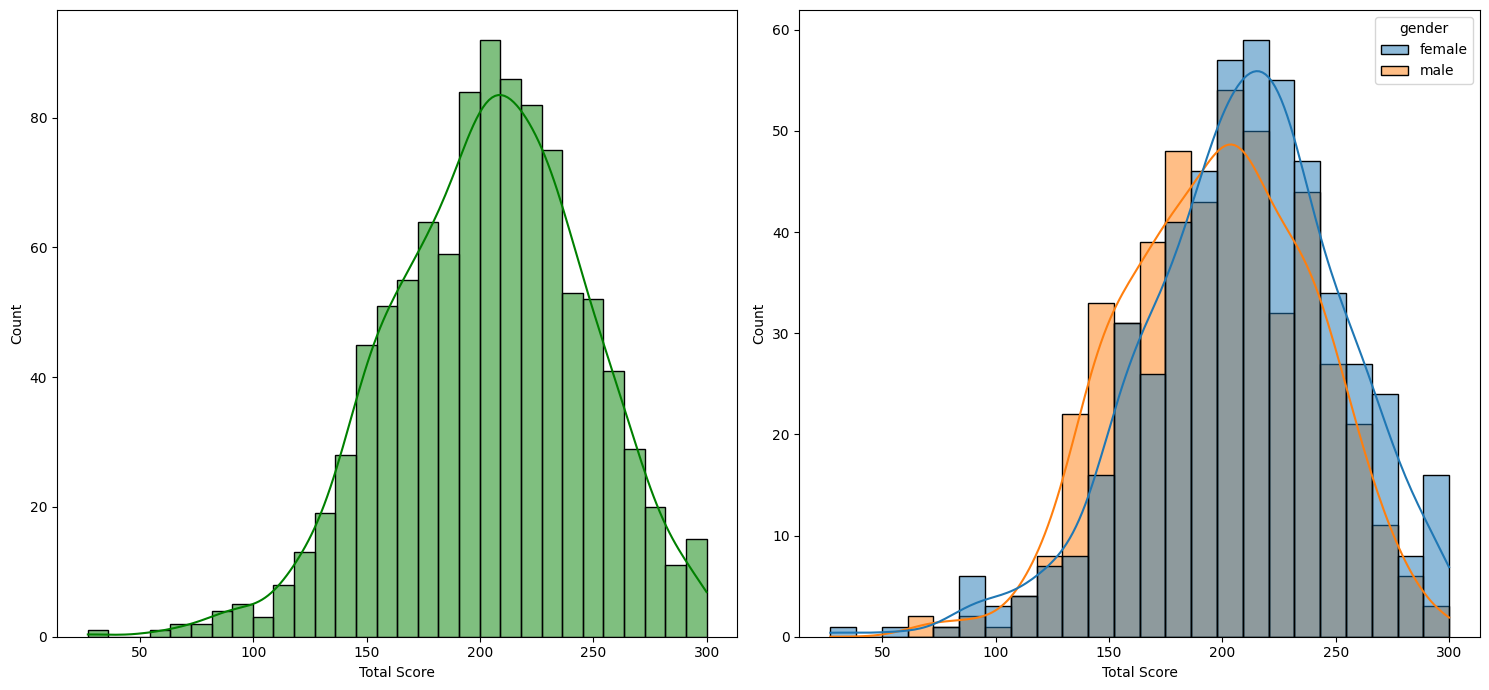

In [14]:
fig, axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Total Score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Total Score',kde=True,hue='gender')
plt.tight_layout()
plt.show()

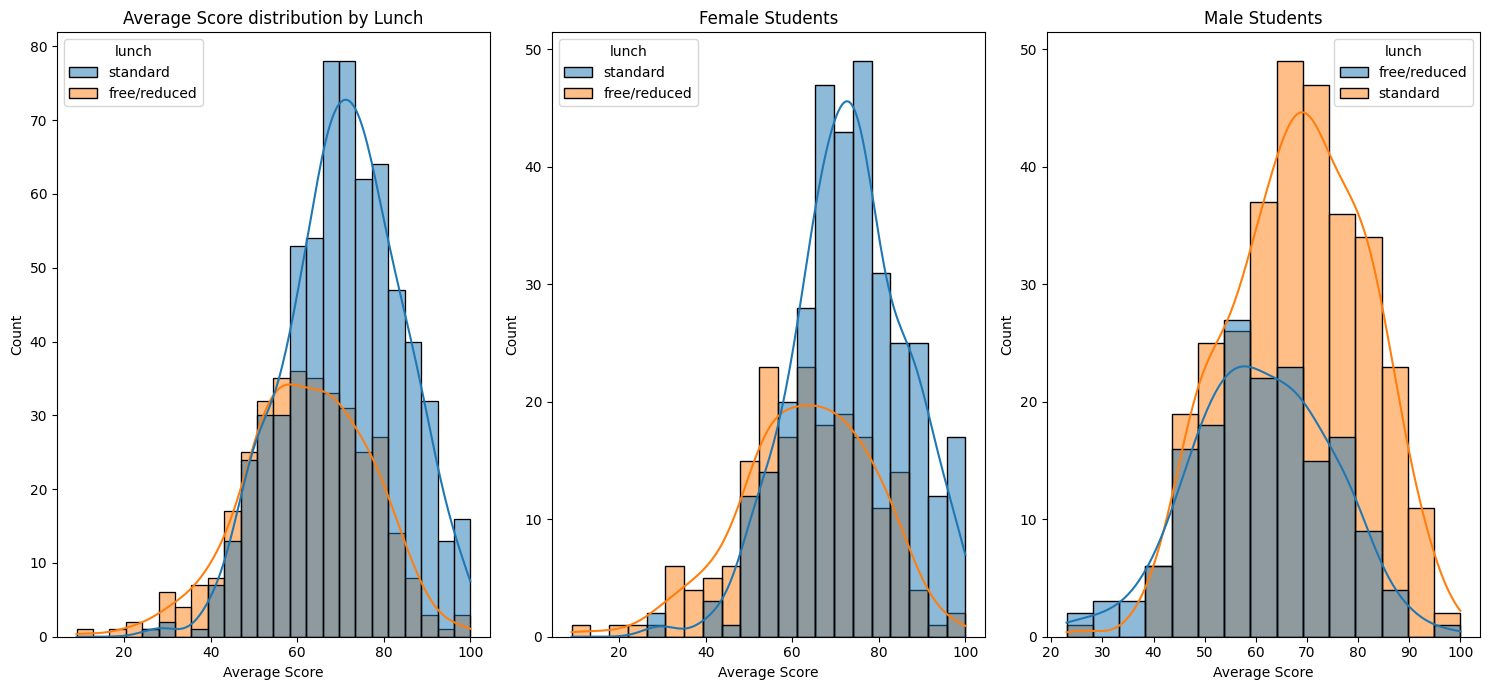

In [15]:
fig,axes =plt.subplots(1,3, figsize=(15,7))
sns.histplot(data=df,x='Average Score',kde=True,hue='lunch',ax=axes[0])
axes[0].set_title('Average Score distribution by Lunch')
sns.histplot(data=df[df.gender=='female'],x='Average Score',kde=True,hue='lunch',ax=axes[1])
axes[1].set_title('Female Students')
sns.histplot(data=df[df.gender=='male'],x='Average Score',kde=True,hue='lunch',ax=axes[2])
axes[2].set_title('Male Students')
plt.tight_layout()
plt.show()

### Additional Improvements:
#### If you want to handle potential missing data:

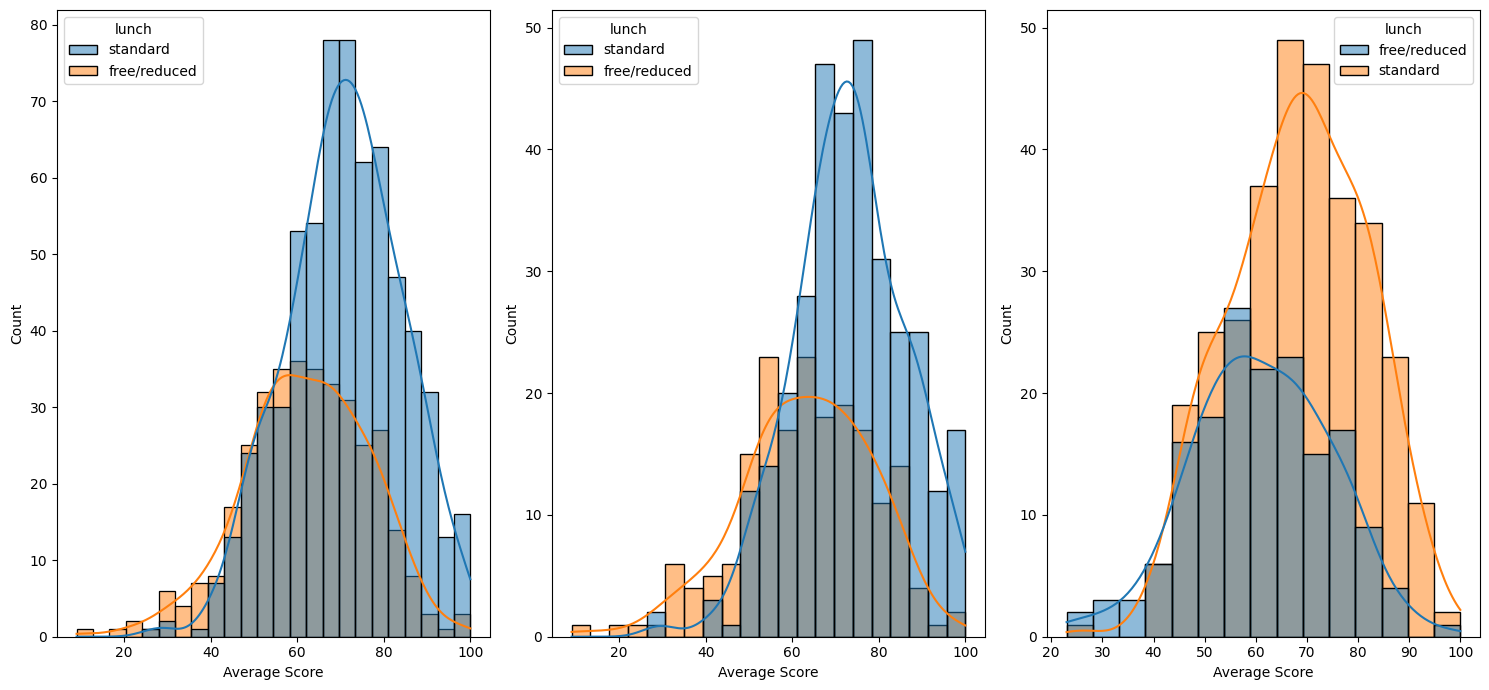

In [16]:
plt.figure(figsize=(15, 7))

# Remove any null values in gender or Average score
clean_df = df.dropna(subset=['gender', 'Average Score', 'lunch'])

plt.subplot(131)
sns.histplot(data=clean_df, x='Average Score', kde=True, hue='lunch')

plt.subplot(132)
female_data = clean_df[clean_df.gender == 'female']
if not female_data.empty:
    sns.histplot(data=female_data, x='Average Score', kde=True, hue='lunch')
else:
    plt.text(0.5, 0.5, 'No female students data', ha='center', va='center')

plt.subplot(133)
male_data = clean_df[clean_df.gender == 'male']
if not male_data.empty:
    sns.histplot(data=male_data, x='Average Score', kde=True, hue='lunch')
else:
    plt.text(0.5, 0.5, 'No male students data', ha='center', va='center')

plt.tight_layout()
plt.show()

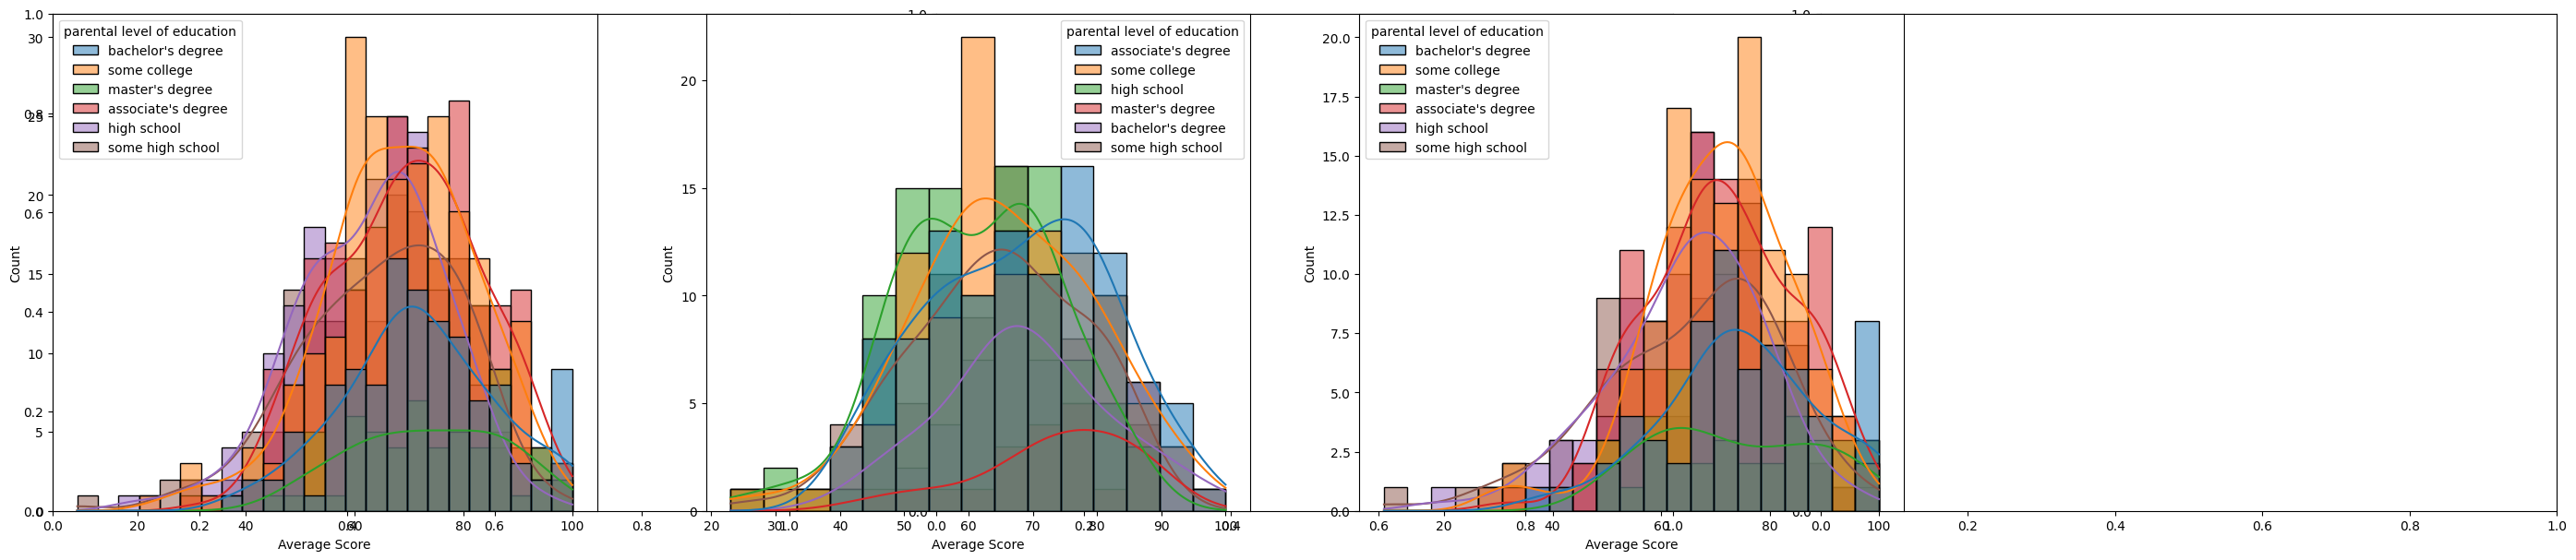

In [17]:
plt.subplots(1,3,figsize=(35,7))
plt.subplot(141)
ax =sns.histplot(data=df,x='Average Score',kde=True,hue='parental level of education')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='male'],x='Average Score',kde=True,hue='parental level of education')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='female'],x='Average Score',kde=True,hue='parental level of education')
plt.tight_layout()
plt.show()

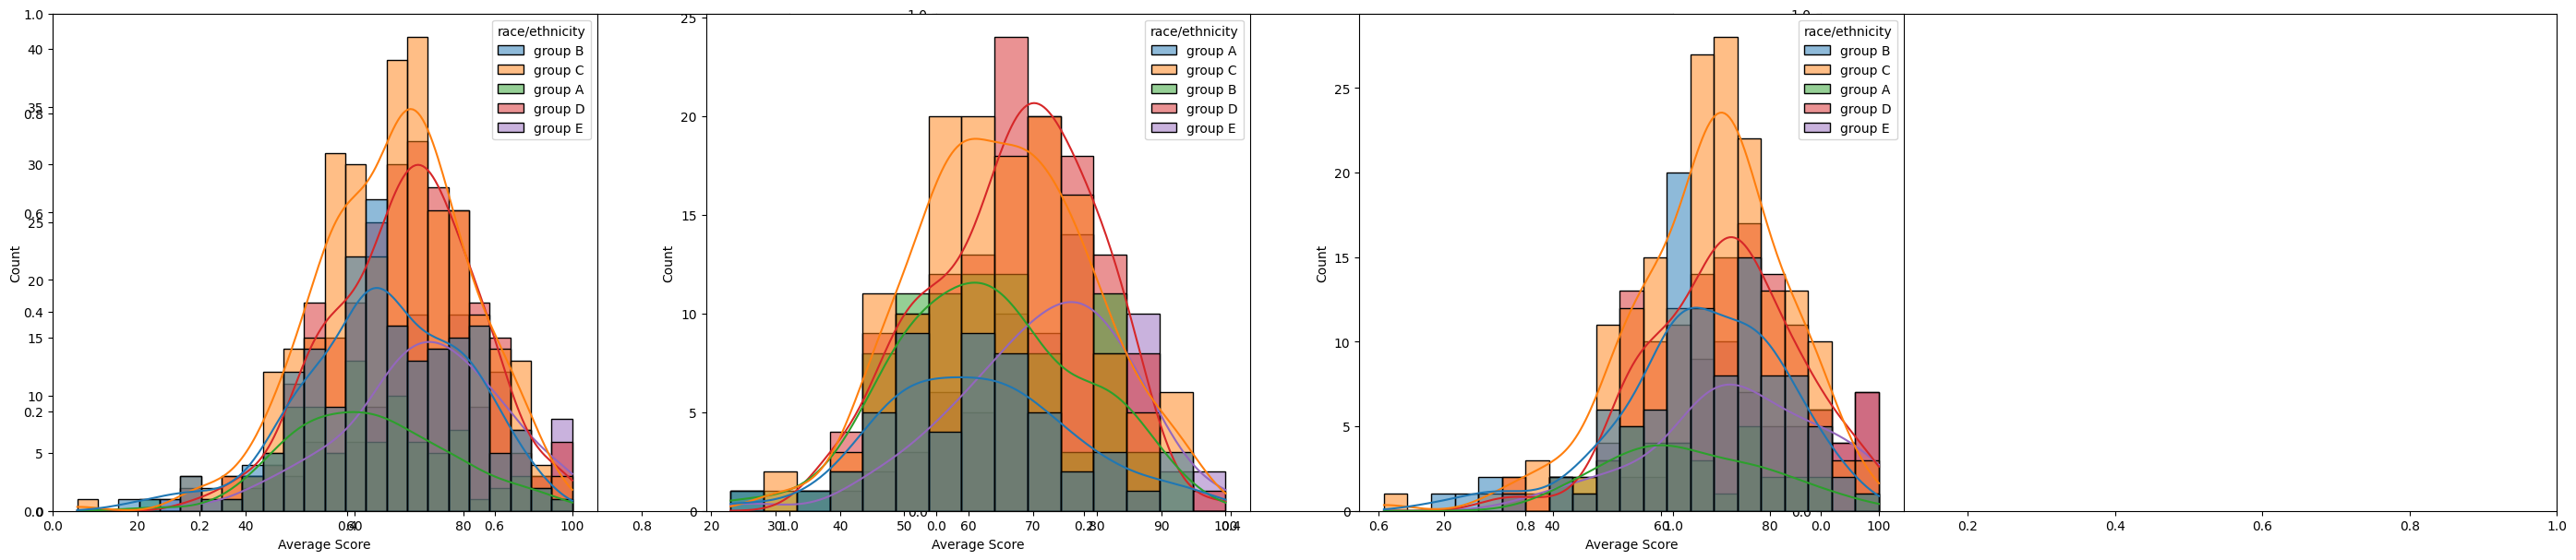

In [18]:
plt.subplots(1,3,figsize=(35,7))
plt.subplot(141)
ax =sns.histplot(data=df,x='Average Score',kde=True,hue='race/ethnicity')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='male'],x='Average Score',kde=True,hue='race/ethnicity')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='female'],x='Average Score',kde=True,hue='race/ethnicity')
plt.tight_layout()
plt.show()      

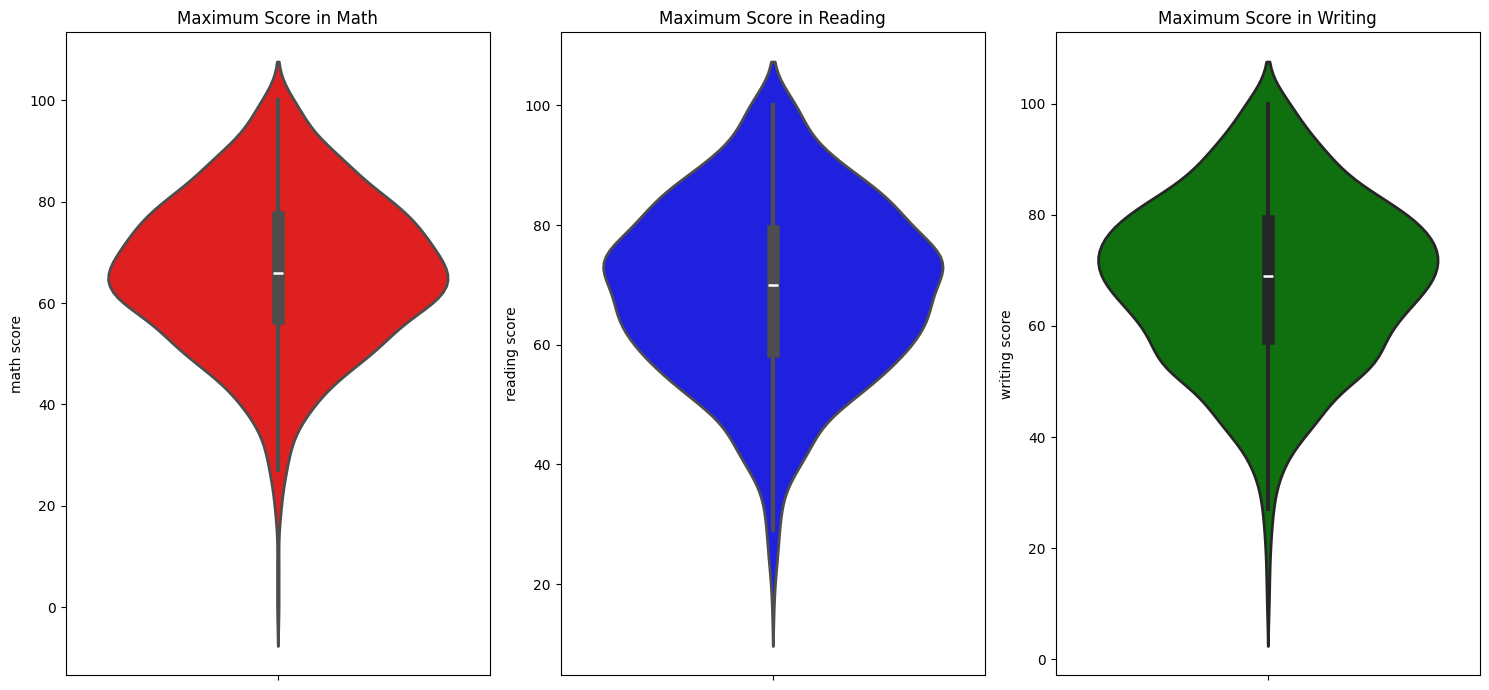

In [19]:
# 4.2 Maximum score of students in all three subjects
plt.figure(figsize=(15, 7))
plt.subplot(131)
plt.title('Maximum Score in Math')
sns.violinplot(y='math score',data=df,color='red',linewidth=2)
plt.subplot(132)
plt.title('Maximum Score in Reading')
sns.violinplot(y='reading score',data=df,color='blue',linewidth=2)
plt.subplot(133)
plt.title('Maximum Score in Writing')
sns.violinplot(y='writing score',data=df,color='green',linewidth=2)
plt.tight_layout()
plt.show()

### 4.3 Multivariate analysis using pieplot

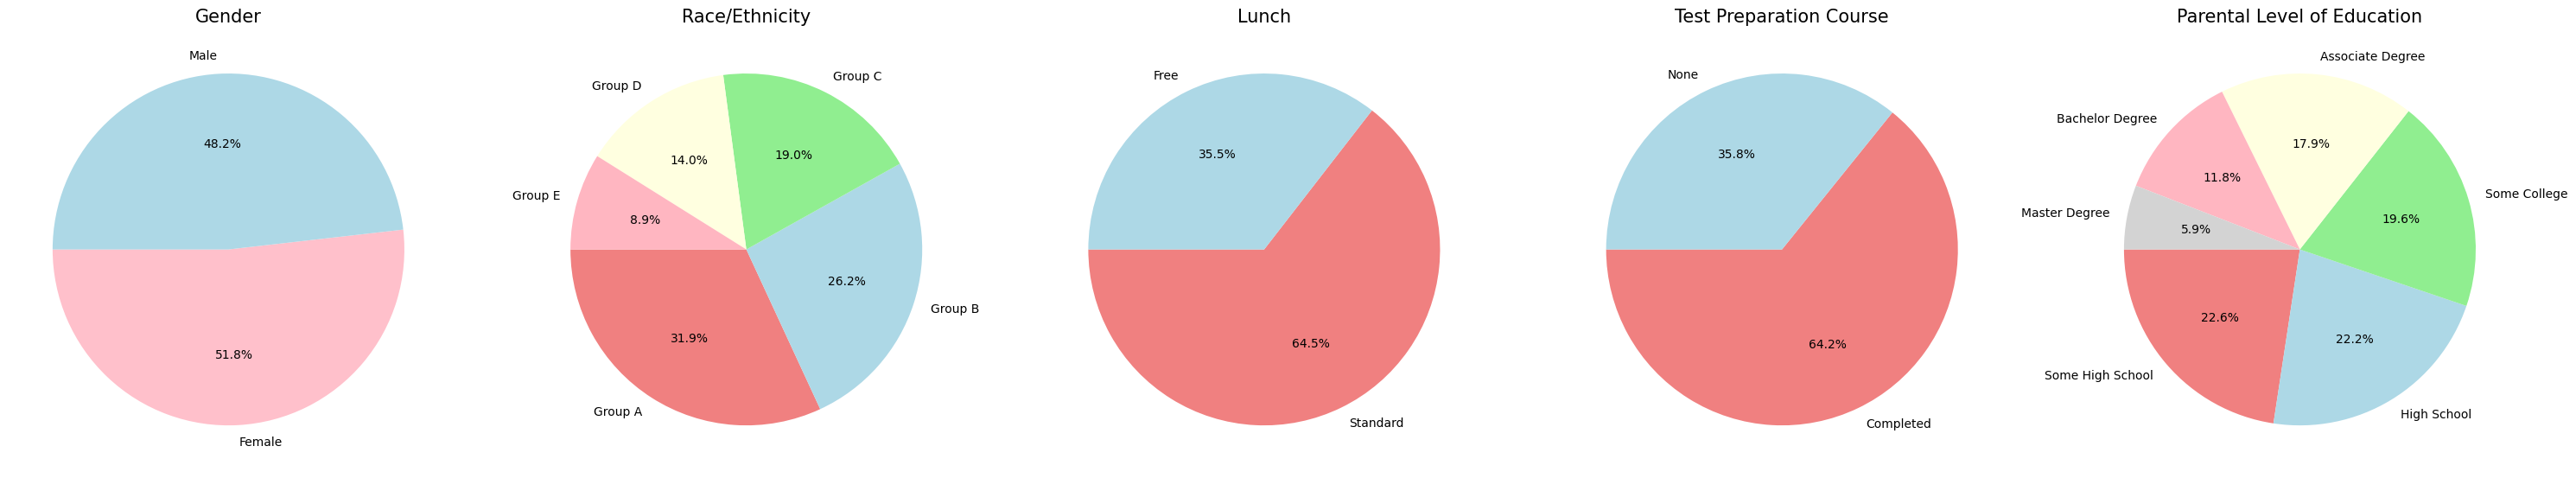

In [20]:
plt.rcParams['figure.figsize']=(30,15)

plt.subplot(1,5,1)
size = df['gender'].value_counts()
labels = 'Female','Male'
colors = ['pink','lightblue']

plt.pie(size,colors=colors,labels=labels,autopct='%1.1f%%',startangle=180)
plt.title('Gender', fontsize=15)
plt.axis('off')

plt.subplot(1,5,2)
size = df['race/ethnicity'].value_counts()
labels = 'Group A','Group B','Group C','Group D','Group E'
colors = ['lightcoral','lightblue','lightgreen','lightyellow','lightpink']
plt.pie(size,colors=colors,labels=labels,autopct='%1.1f%%',startangle=180)
plt.title('Race/Ethnicity', fontsize=15)
plt.axis('off') 

plt.subplot(1,5,3)
size = df['lunch'].value_counts()
labels = 'Standard','Free'
colors = ['lightcoral','lightblue']
plt.pie(size,colors=colors,labels=labels,autopct='%1.1f%%',startangle=180)
plt.title('Lunch', fontsize=15)
plt.axis('off')

plt.subplot(1,5,4)
size = df['test preparation course'].value_counts()
labels = 'Completed','None'
colors = ['lightcoral','lightblue']
plt.pie(size,colors=colors,labels=labels,autopct='%1.1f%%',startangle=180)
plt.title('Test Preparation Course', fontsize=15)
plt.axis('off')

plt.subplot(1,5,5)
size = df['parental level of education'].value_counts()
labels = ['Some High School','High School','Some College','Associate Degree','Bachelor Degree','Master Degree']
colors = ['lightcoral','lightblue','lightgreen','lightyellow','lightpink','lightgray']
plt.pie(size,colors=colors,labels=labels,autopct='%1.1f%%',startangle=180)
plt.title('Parental Level of Education', fontsize=15)
plt.axis('off')


plt.tight_layout()
plt.grid()
plt.show()

#### Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree

#### 4.4 Feature Wise Visualization
##### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?
#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

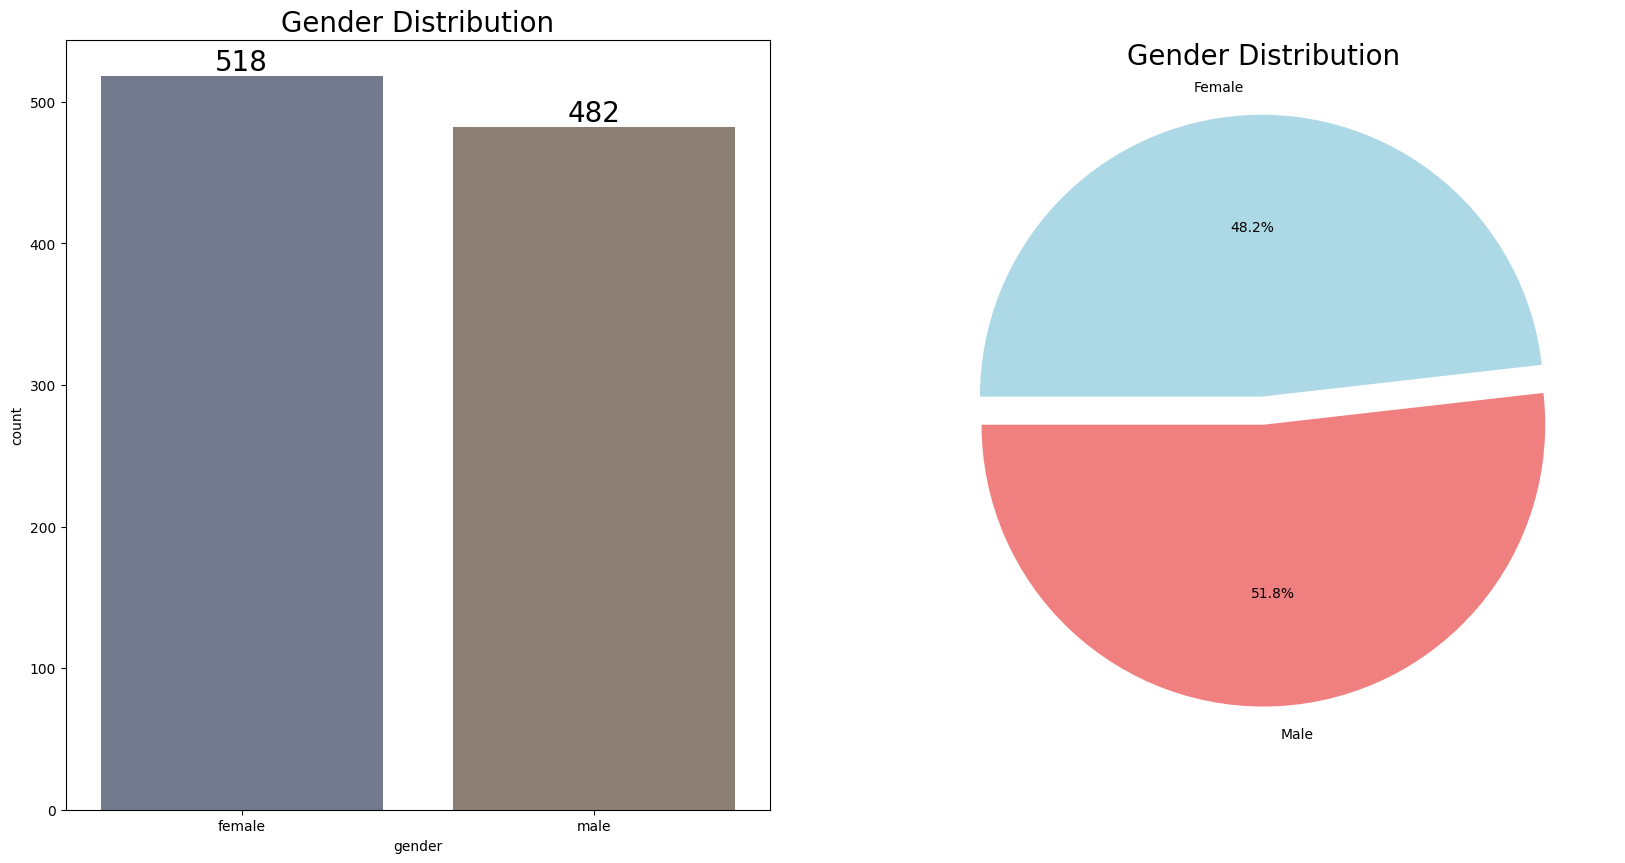

In [21]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette='bright',ax=ax[0],saturation=0.10)
ax[0].set_title('Gender Distribution',size=20)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',colors=colors,startangle=180)
ax[1].set_title('Gender Distribution',size=20)
plt.show()



### Insights
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)

### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

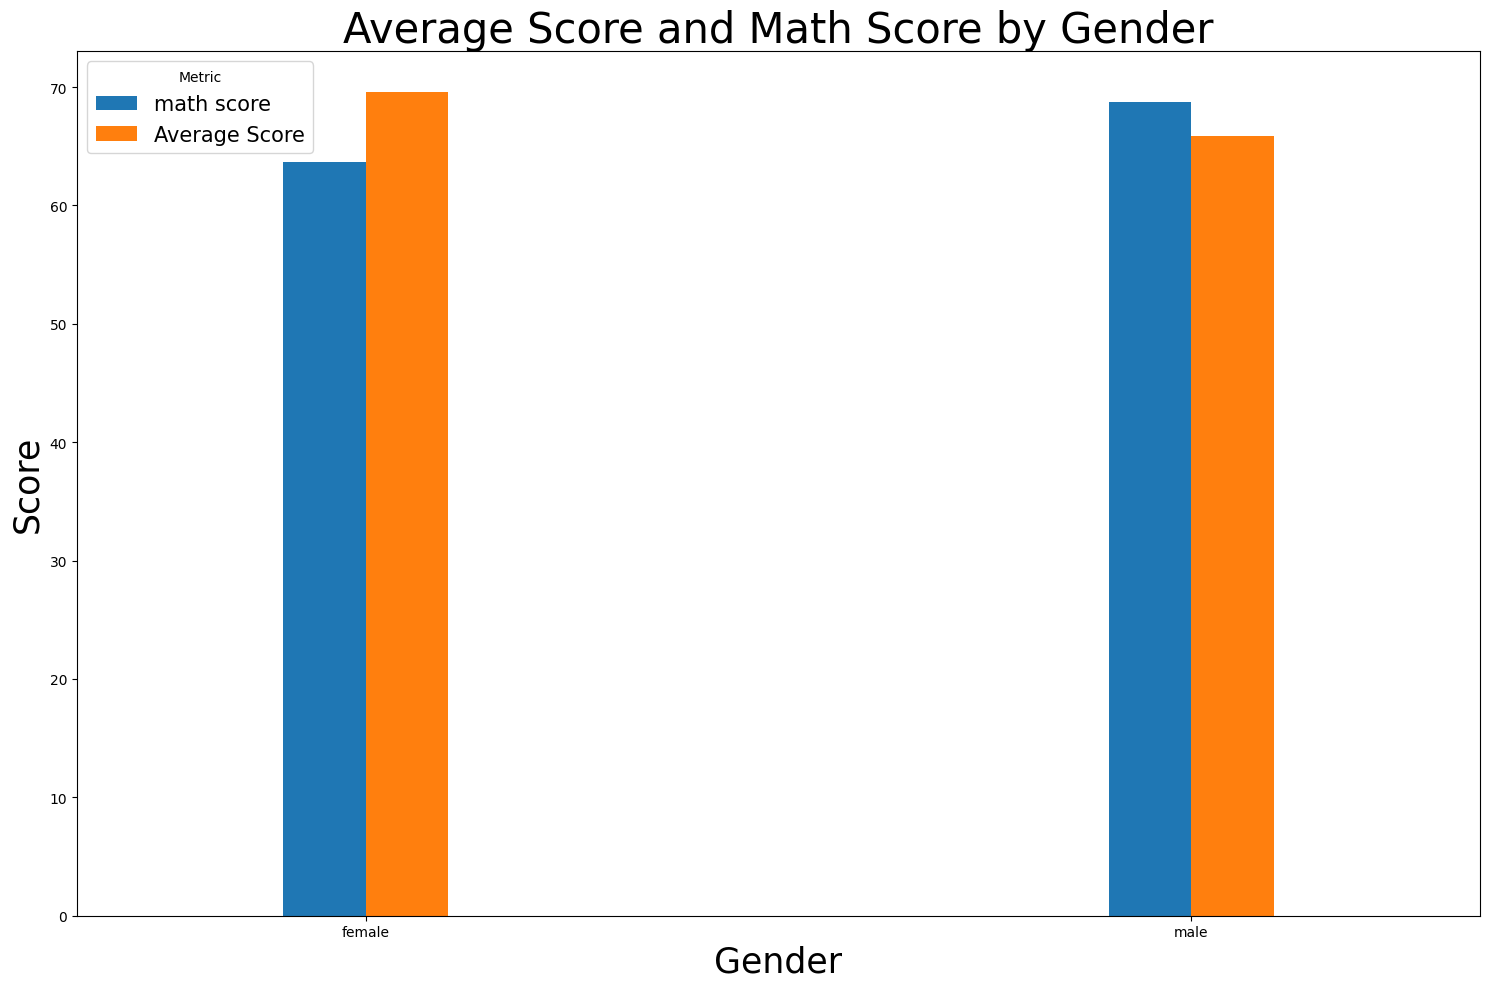

In [22]:
cols = ['math score', 'Average Score']

gender_group = (
    df.loc[:, ['gender'] + cols]
      .assign(**{c: pd.to_numeric(df[c], errors='coerce') for c in cols})
      .groupby('gender', observed=True)[cols]
      .mean()
)

ax = gender_group.plot(kind='bar', figsize=(15, 10), width=0.2)
ax.set_title('Average Score and Math Score by Gender', fontsize=30)
ax.set_xlabel('Gender', fontsize=25)
ax.set_ylabel('Score',fontsize=25)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Metric',fontsize=15)
plt.tight_layout()
plt.show()

### Insights
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?
### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

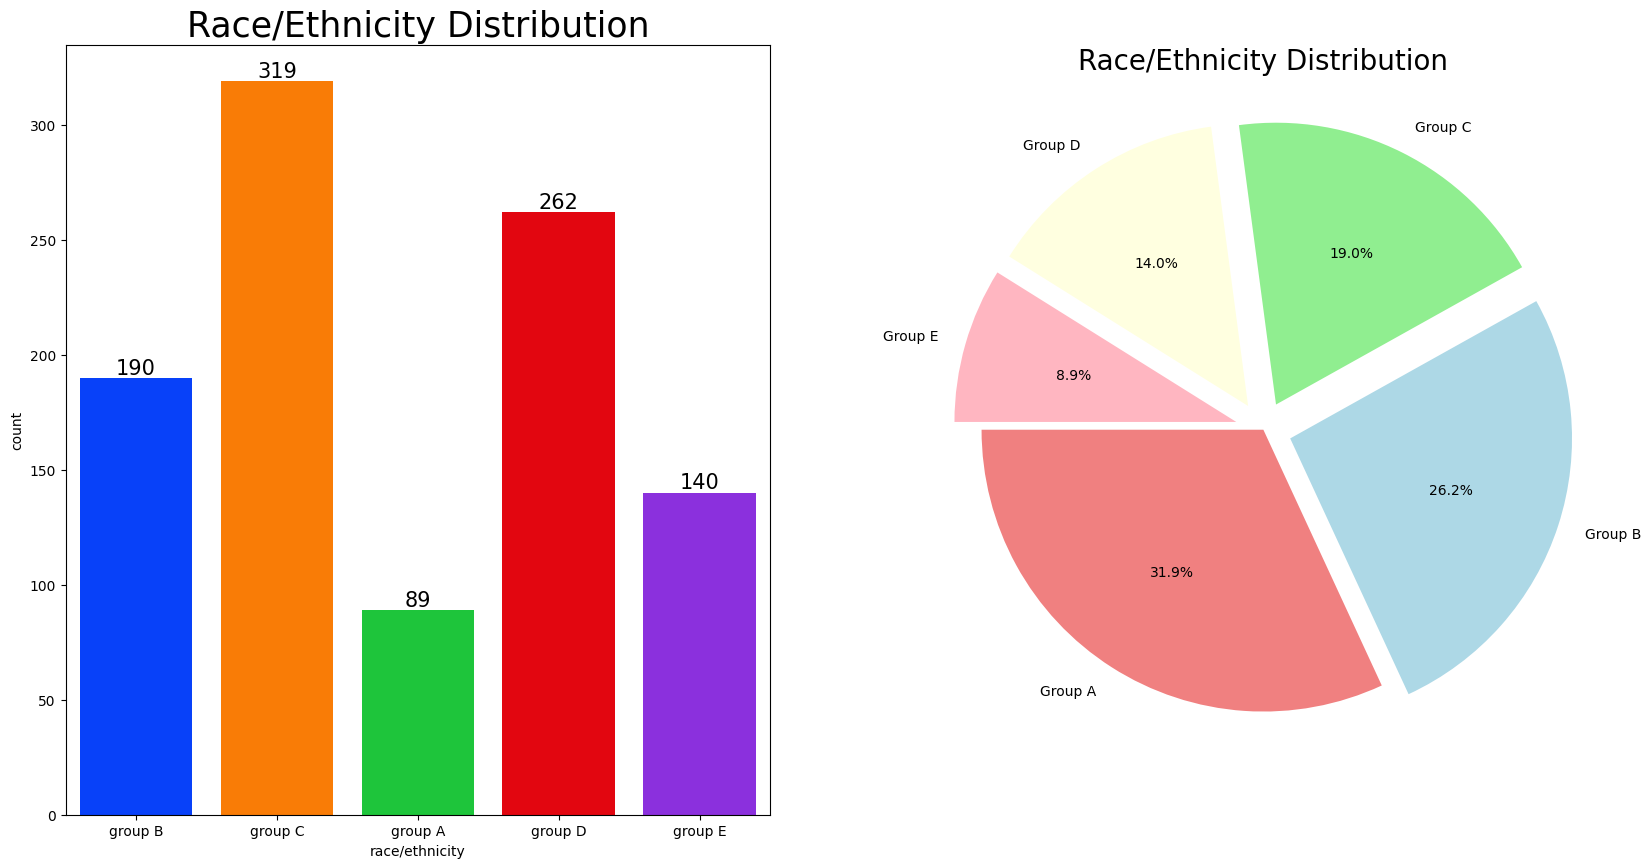

In [23]:
f, ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race/ethnicity'],data=df,palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)
ax[0].set_title('Race/Ethnicity Distribution',size=25)
plt.pie(x=df['race/ethnicity'].value_counts(),labels=['Group A','Group B','Group C','Group D','Group E'],explode=[0,0.1,0.1,0.1,0.1],autopct='%1.1f%%',colors=colors,startangle=180)
ax[1].set_title('Race/Ethnicity Distribution',size=20)
plt.show()  

### Insights
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

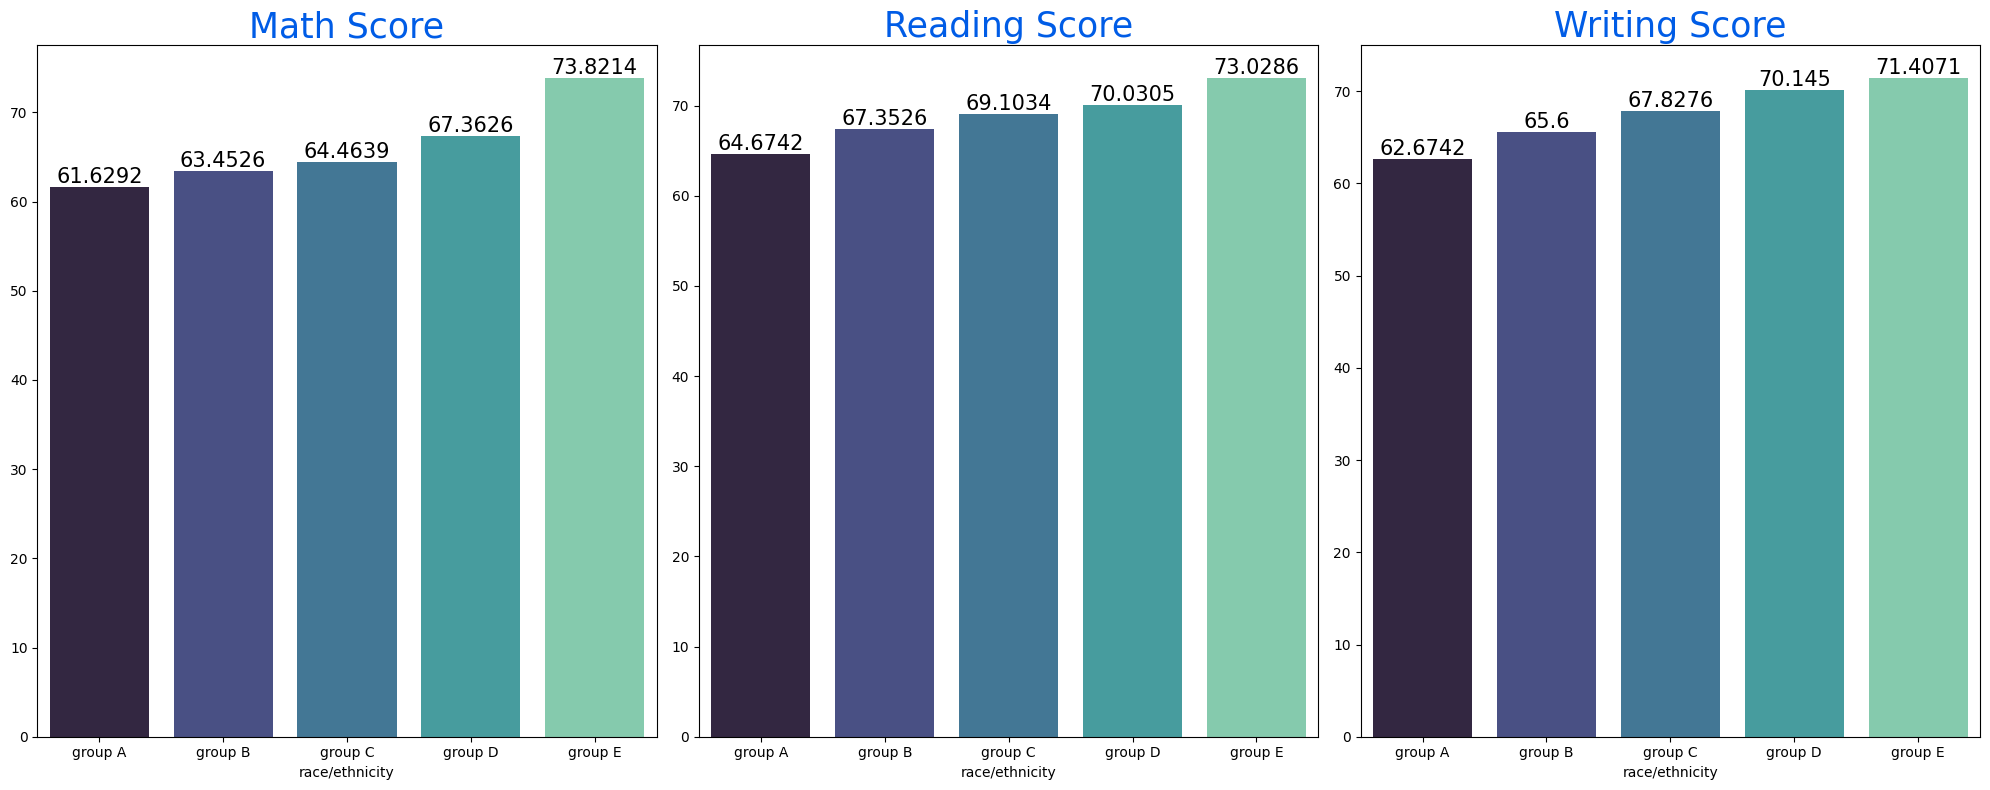

In [24]:
Group_data2=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math score'].mean().index,
            y=Group_data2['math score'].mean().values,palette='mako',ax=ax[0])
ax[0].set_title('Math Score',color='#005ce6',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)
sns.barplot(x=Group_data2['reading score'].mean().index,
            y=Group_data2['reading score'].mean().values,palette='mako', ax=ax[1])
ax[1].set_title('Reading Score',color='#005ce6',size=25)
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)
sns.barplot(x=Group_data2['writing score'].mean().index,
            y=Group_data2['writing score'].mean().values,palette='mako', ax=ax[2])
ax[2].set_title('Writing Score',color='#005ce6',size=25)
for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)
plt.tight_layout()
plt.show()



### Insights
- Group E students have scored the highest marks.
- Group A students have scored the lowest marks.
- Students from a lower Socioeconomic status have a lower avg in all course subjects

### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?
### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

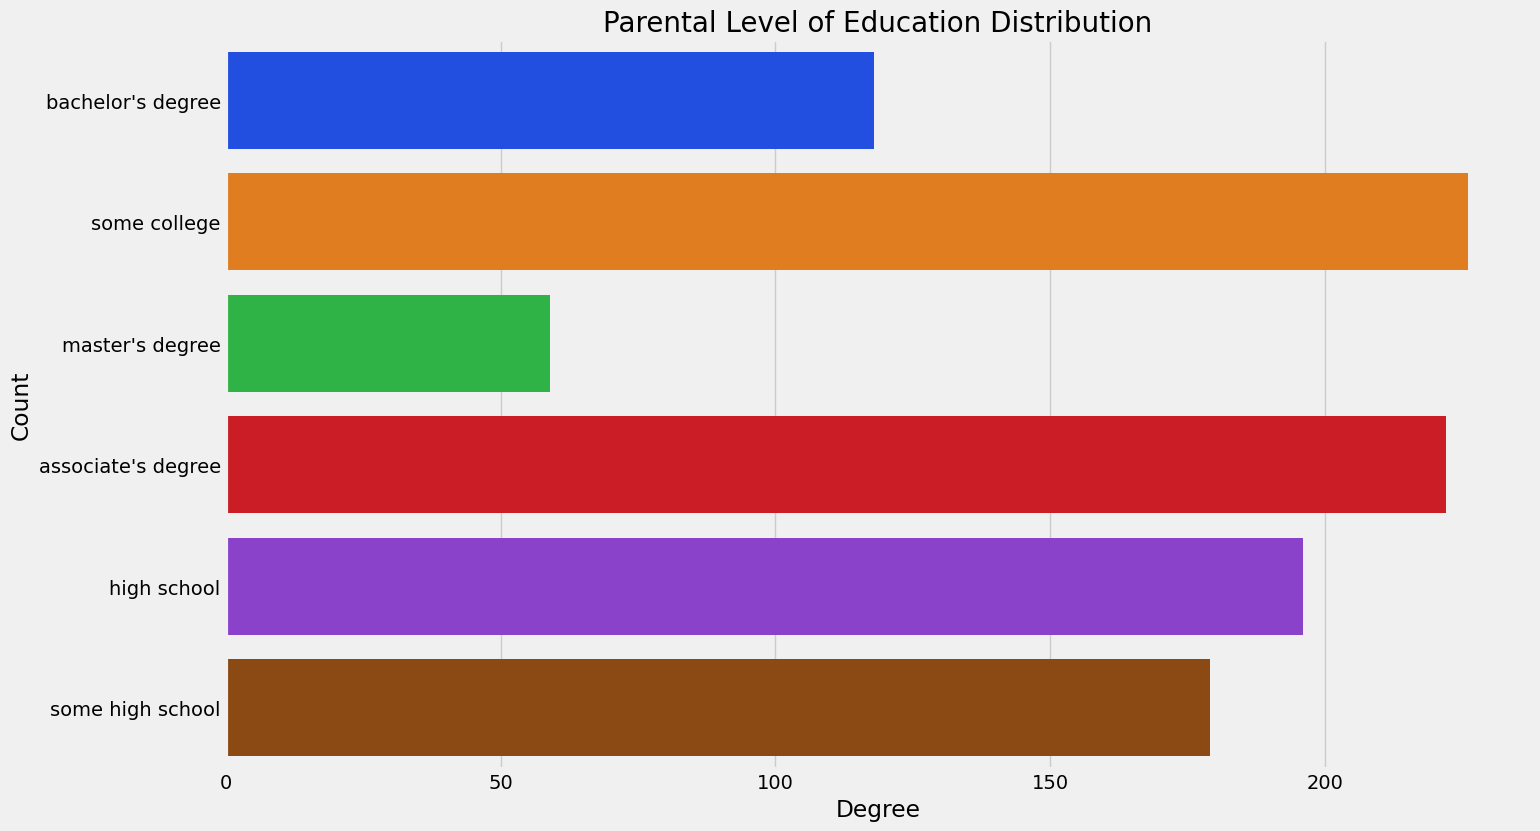

In [25]:
plt.rcParams['figure.figsize']=(15,9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental level of education'],palette='bright',color='#005ce6')
plt.title('Parental Level of Education Distribution',fontweight=30,size=20)
plt.xlabel('Degree')
plt.ylabel('Count')
plt.show()

### Insights
- Largest number of parents are from some college.

### MULTIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

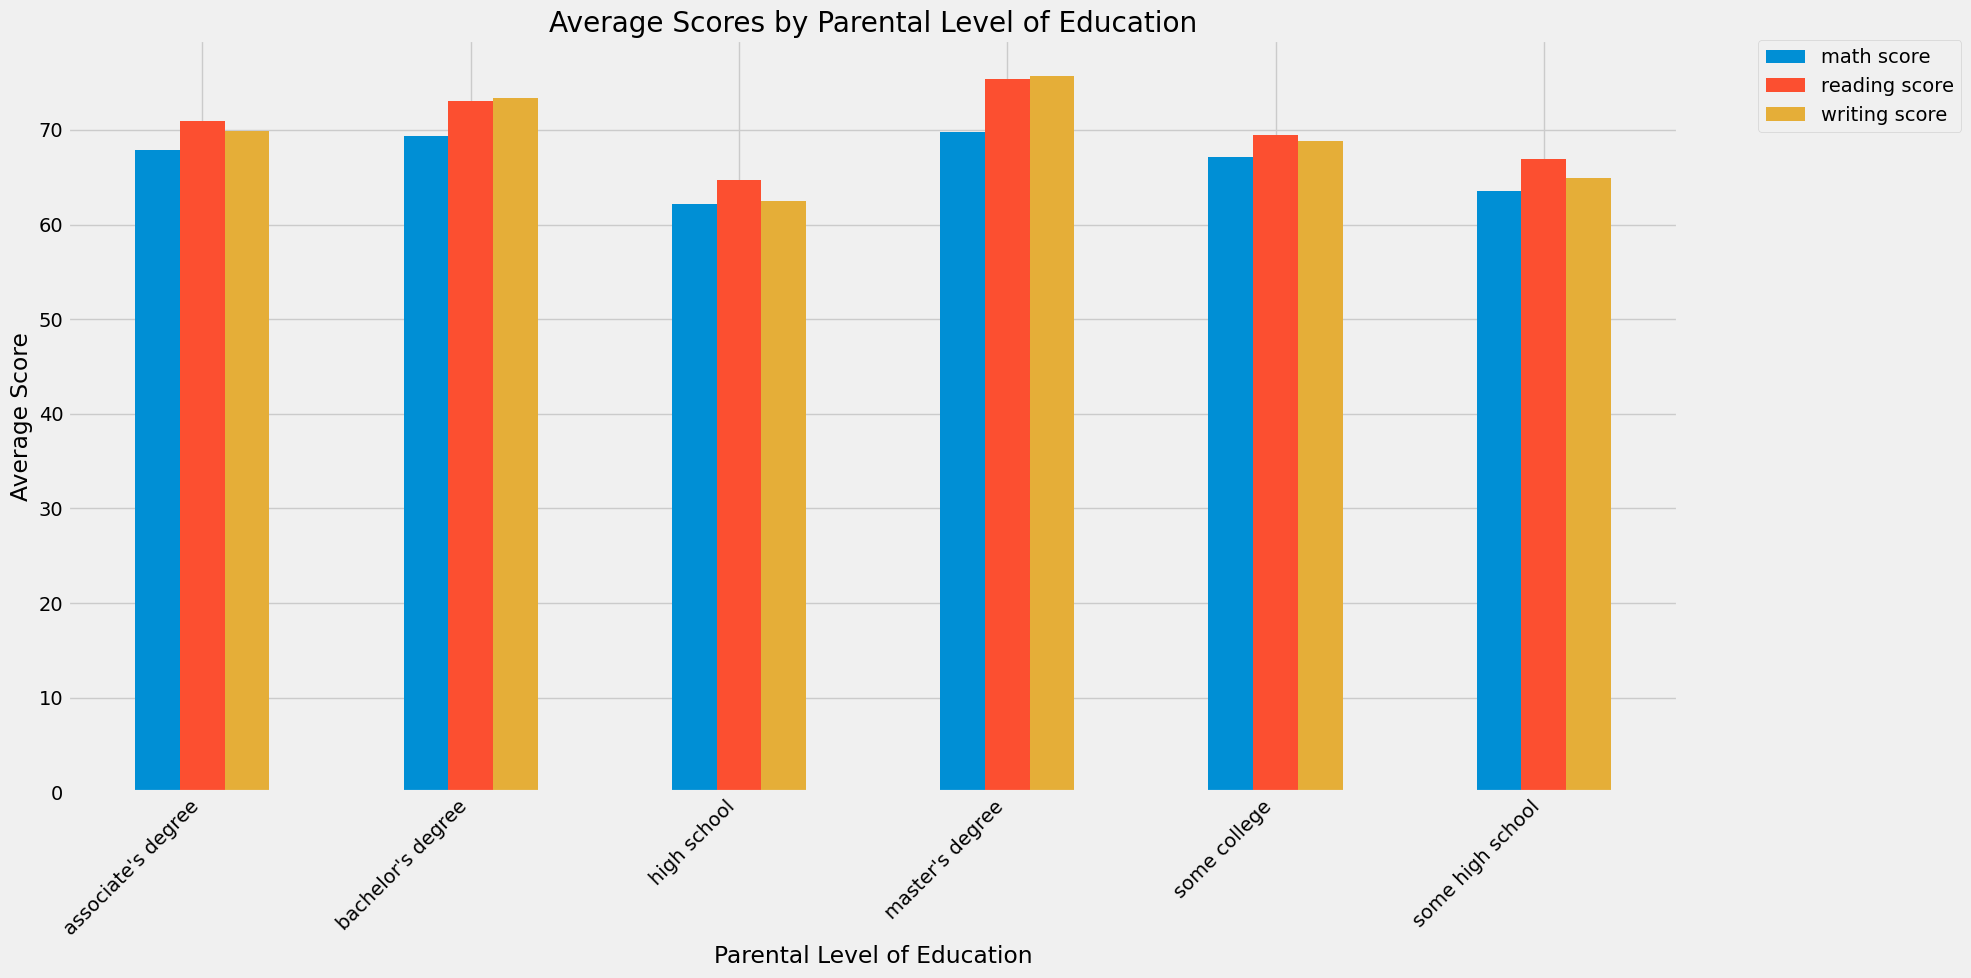

In [26]:
df.groupby('parental level of education')[['math score', 'reading score', 'writing score']].mean().plot(kind='bar', figsize=(20,10))
plt.title('Average Scores by Parental Level of Education')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Insights
- The score of student whose parents possess master and bachelor level education are higher than others.

### 4.4.4 LUNCH COLUMN
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?
### UNIVARIATE ANALYSIS (Which type of lunch is most common amoung students ?)

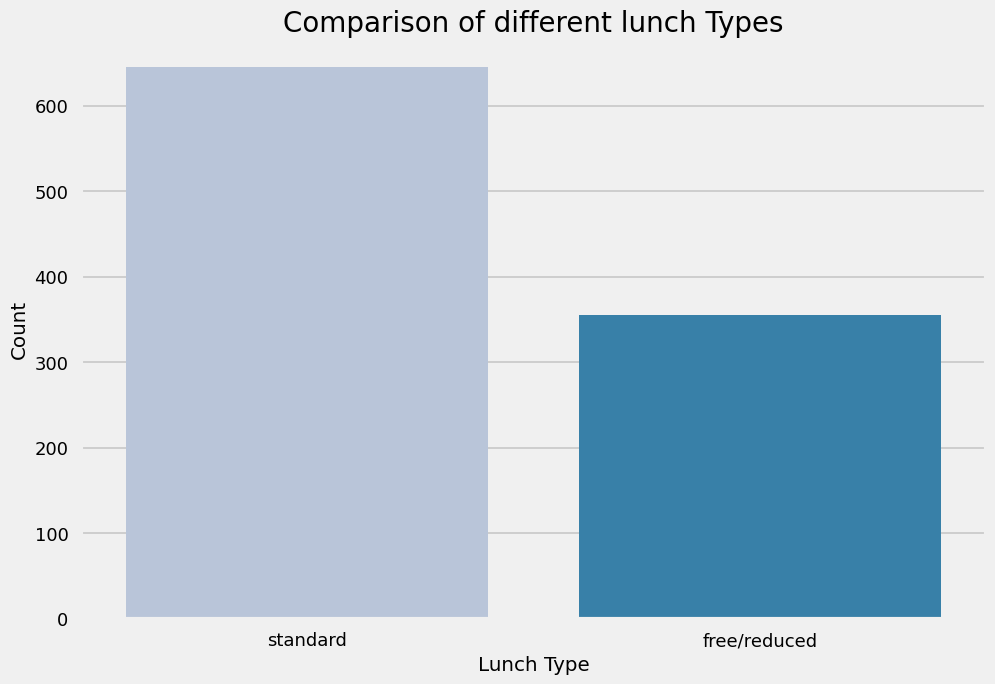

In [27]:
plt.rcParams['figure.figsize']=(15,10)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(x=df['lunch'],palette='PuBu')
plt.title('Comparison of different lunch Types',fontweight=15,size=20)
plt.xlabel('Lunch Type')
plt.ylabel('Count')
plt.show()

### Insights
- Students being served Standard lunch was more than free lunch

### BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, "bachelor's degree"),
  Text(1, 0, 'some college'),
  Text(2, 0, "master's degree"),
  Text(3, 0, "associate's degree"),
  Text(4, 0, 'high school'),
  Text(5, 0, 'some high school')])

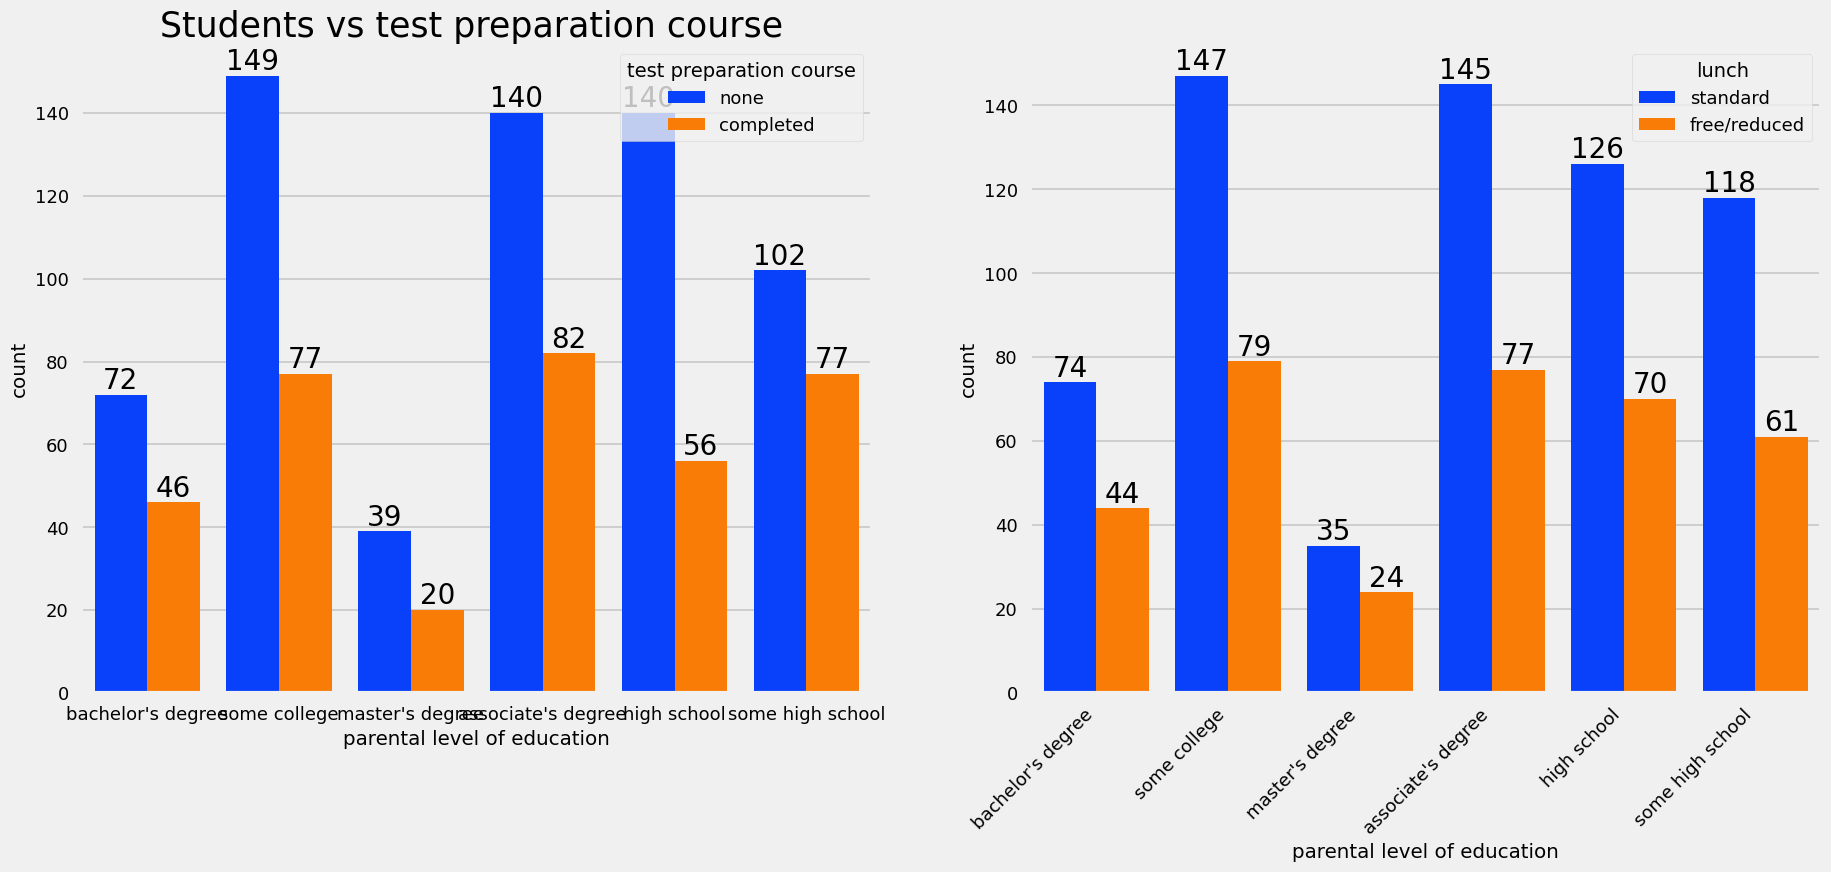

In [28]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='test preparation course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
plt.xticks(rotation=45, ha='right')
    
sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20) 
plt.xticks(rotation=45, ha='right')

### Insights
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

### 4.4.5 TEST PREPARATION COURSE COLUMN
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?

### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

<Axes: xlabel='lunch', ylabel='writing score'>

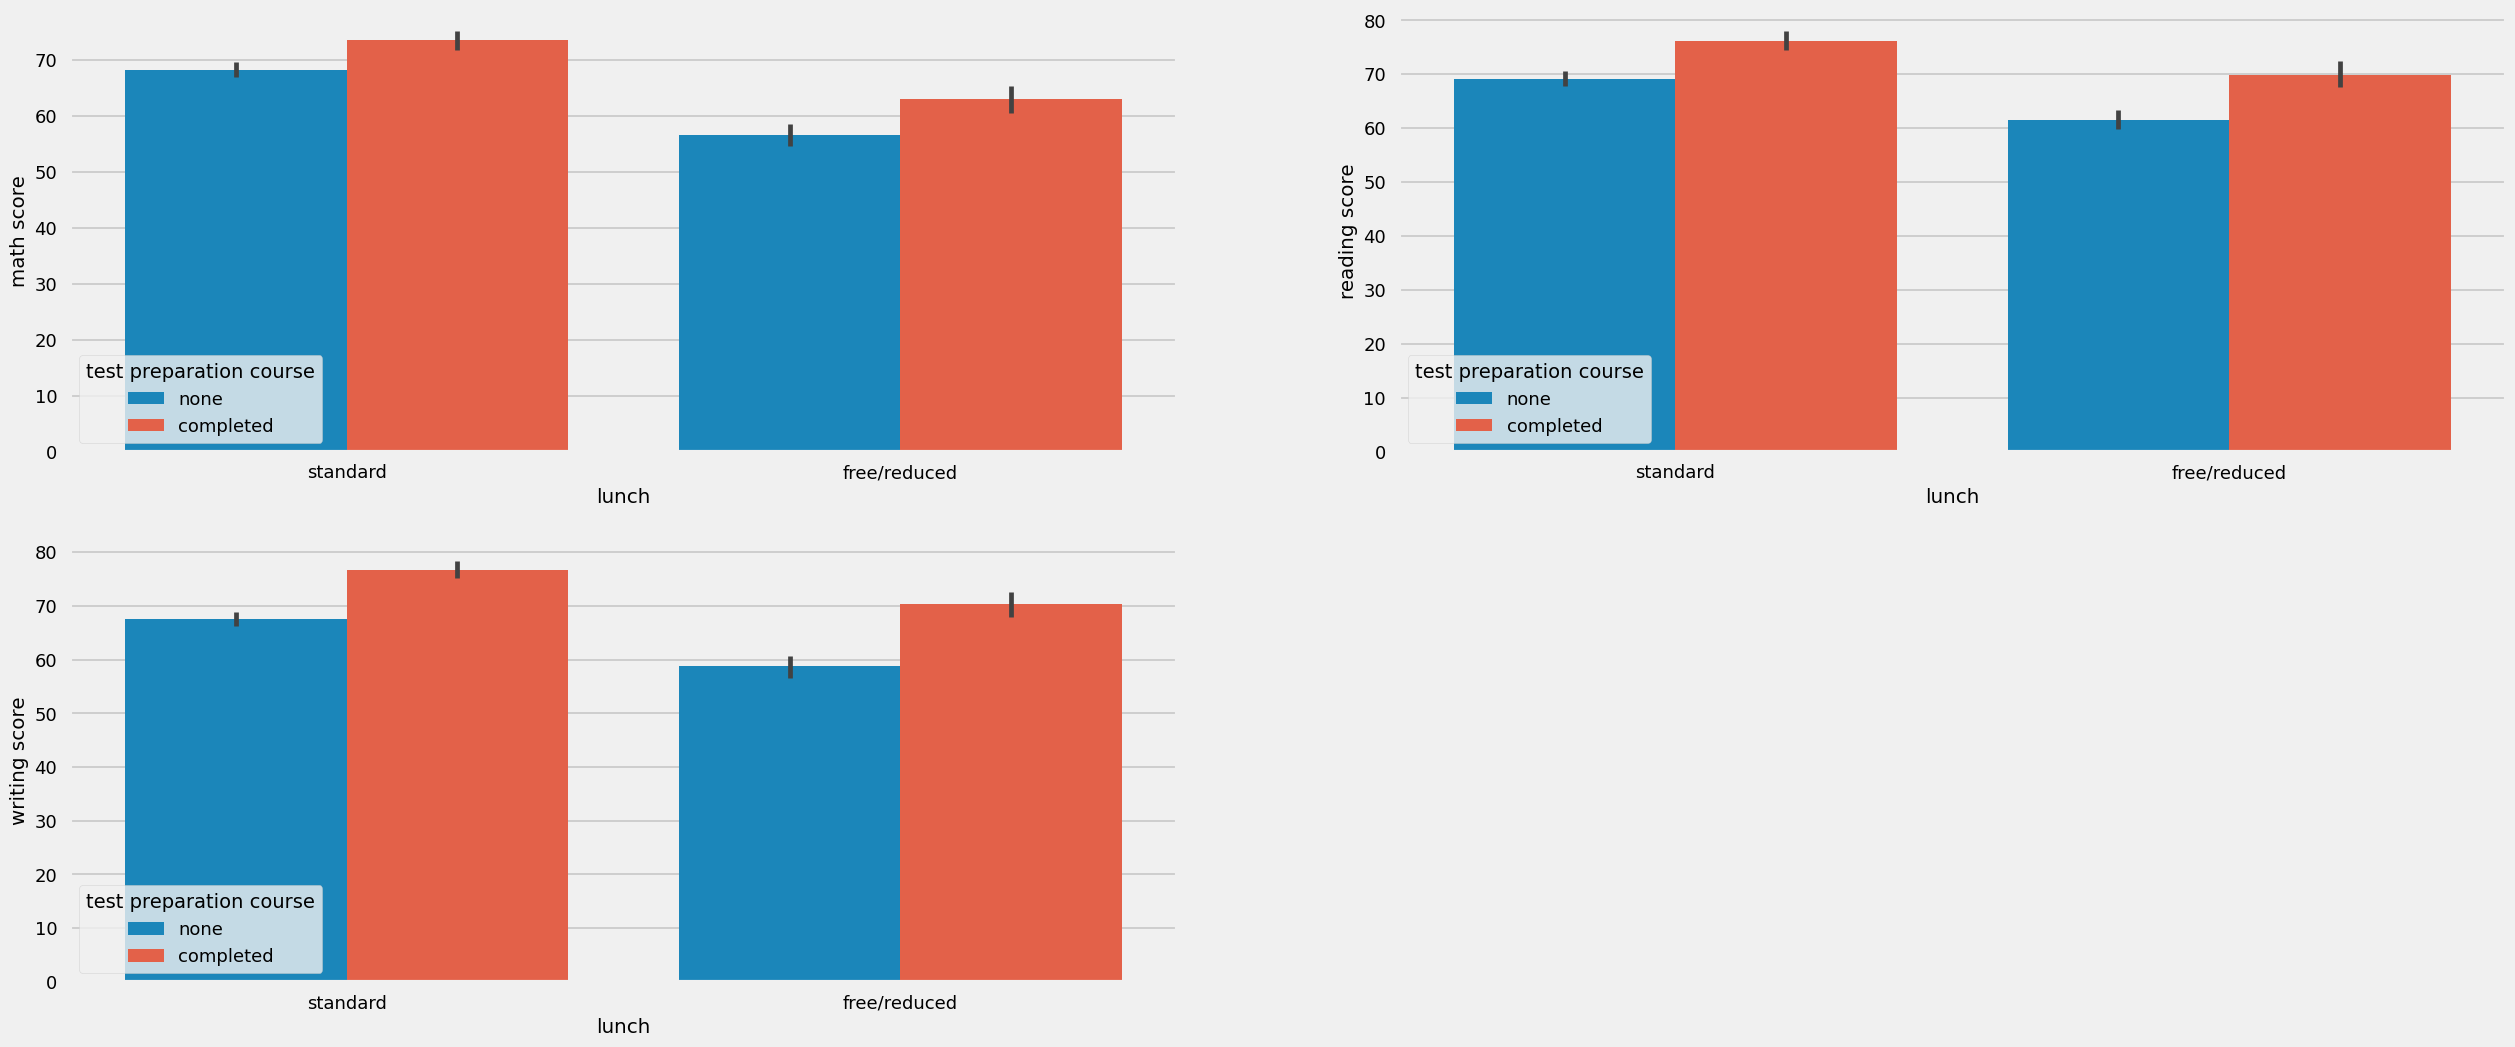

In [29]:
plt.figure(figsize=(28,12))
plt.subplot(2,2,1)
sns.barplot(x=df['lunch'], y=df['math score'], hue=df['test preparation course'])
plt.subplot(2,2,2)
sns.barplot(x=df['lunch'], y=df['reading score'], hue=df['test preparation course'])
plt.subplot(2,2,3)
sns.barplot(x=df['lunch'], y=df['writing score'], hue=df['test preparation course'])


### Insights
- Students who have completed the Test Prepration Course have scores higher in all three categories than those - who haven't taken the course

### 4.4.6 CHECKING OUTLIERS

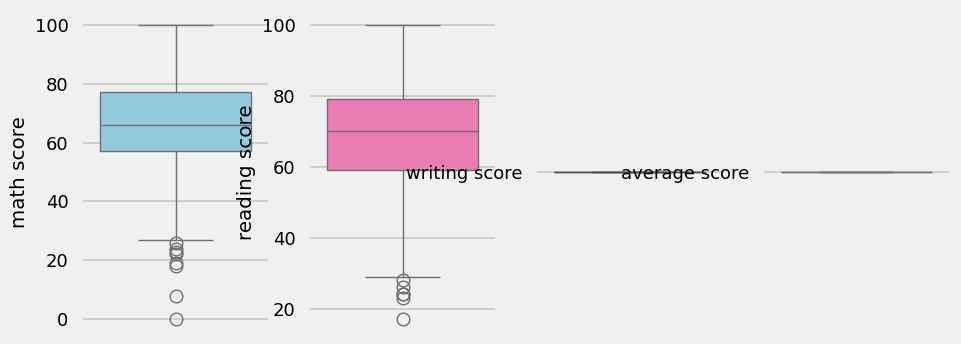

In [38]:
plt.subplots(1,4,figsize=(10,4))
plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(['average score'],color='lightgreen')
plt.show()


### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

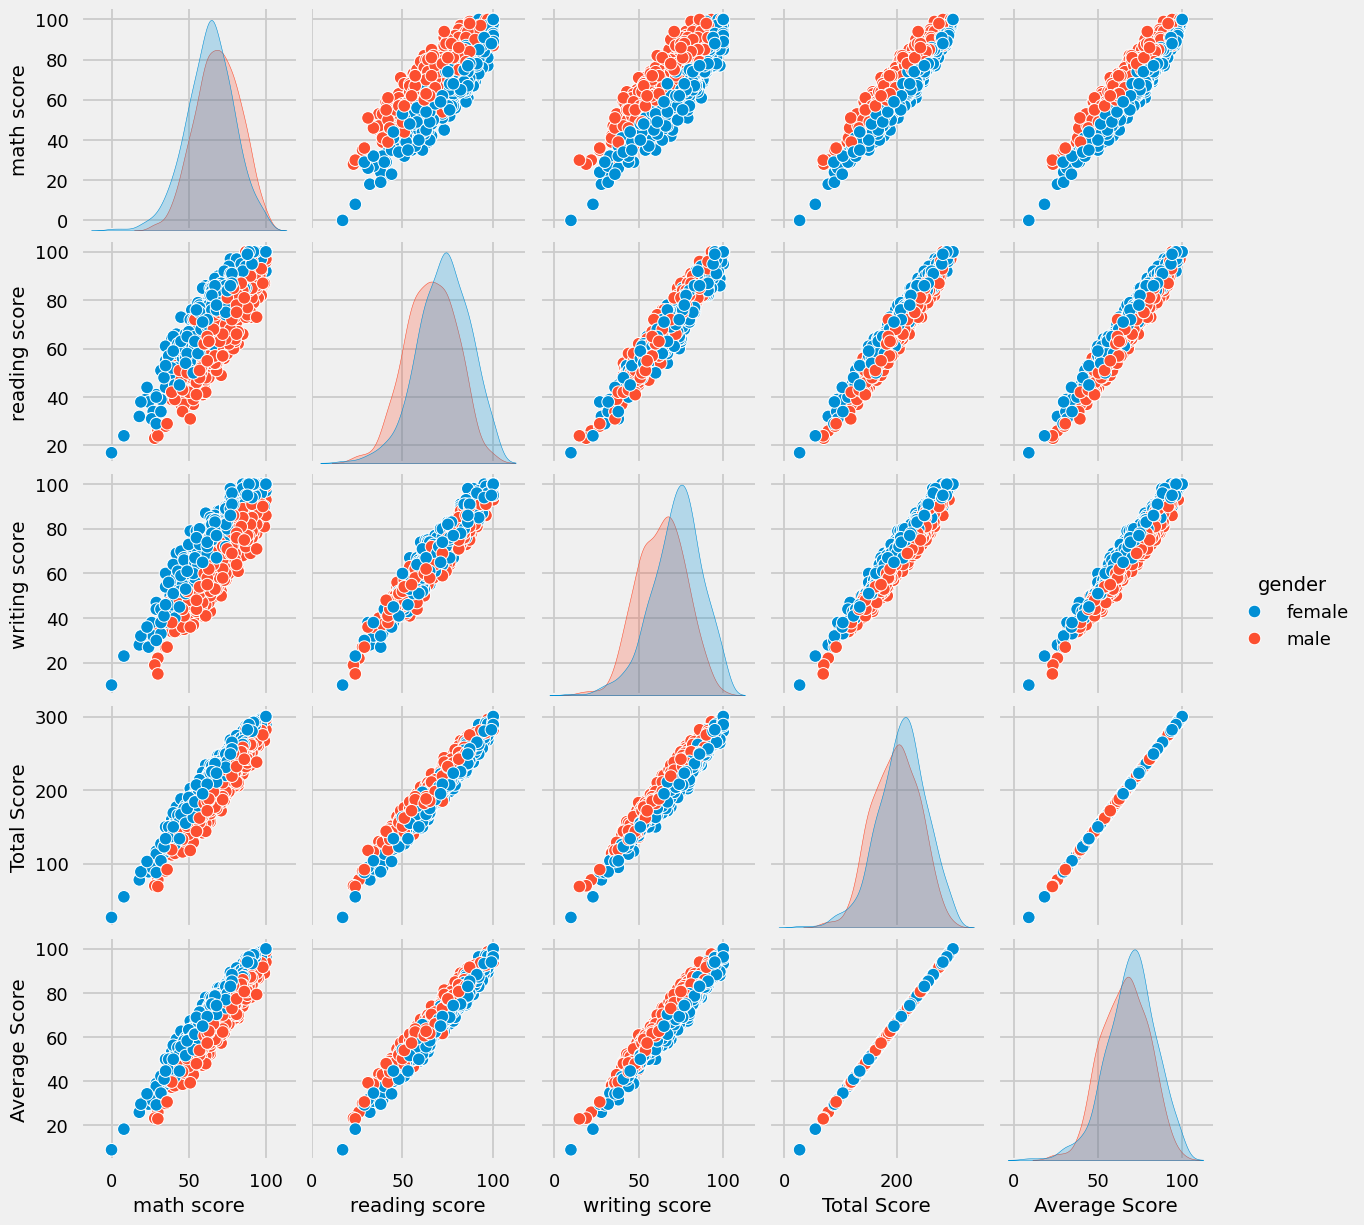

In [39]:
sns.pairplot(df,hue = 'gender')
plt.show()

### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.